<a href="https://colab.research.google.com/github/hkumi/Be12pp-simulation/blob/main/SiPMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [95]:

sensor_1 = pd.read_csv("/content/photon_positions_1.csv",header=None)

In [96]:

sensor_1.shape

(1162, 4)

In [97]:
sensor_1.head()

,0,1,2,3
0,-68.0,3.965750,-1.479570,17
1,-68.0,2.749100,0.368300,17
2,-68.0,3.787900,0.545256,17
3,-68.0,-0.561993,0.998622,16
4,-68.0,-0.992452,1.432680,16


In [98]:
sensor_1.isnull().sum()

,0
0,0
1,0
2,0
3,0


In [99]:
sensor_1[3].value_counts()

,count
3,
16,658
15,195
17,151
18,16
13,14
14,11
19,11
7,11
20,8


<Axes: xlabel='3', ylabel='Count'>

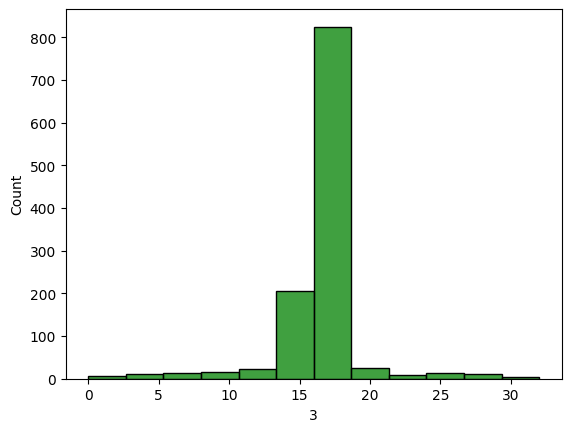

In [100]:

sns.histplot(sensor_1[3],color="green")

Mean (μ): 15.90
Standard Deviation (σ): 2.96
FWHM: 6.97
Resolution: 0.44


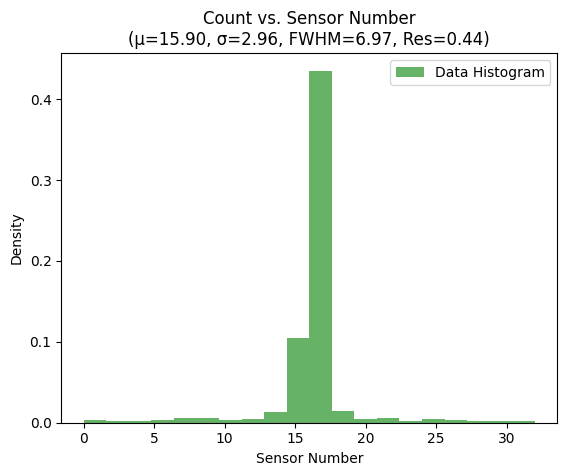

In [101]:
from scipy.optimize import curve_fit




# Data (use your own dataset here)
data = sensor_1[3].values

# Plot the histogram
counts, bins, _ = plt.hist(data, bins=20, density=True, alpha=0.6, color='g', label='Data Histogram')

# Calculate bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])  # Calculate bin centers

# Calculate mean and standard deviation directly from the data
mean_value = np.mean(data)
std_dev_value = np.std(data)

# Calculate the Full Width at Half Maximum (FWHM) based on the standard deviation
fwhm = 2.355 * std_dev_value  # FWHM = 2.355 * sigma (for Gaussian-like distributions)

# Calculate the resolution
resolution = (fwhm / mean_value)   # Resolution in percentage

# Print the calculated values
print(f"Mean (μ): {mean_value:.2f}")
print(f"Standard Deviation (σ): {std_dev_value:.2f}")
print(f"FWHM: {fwhm:.2f}")
print(f"Resolution: {resolution:.2f}")

# Add labels and title to the plot
plt.title(f'Count vs. Sensor Number\n(μ={mean_value:.2f}, σ={std_dev_value:.2f}, FWHM={fwhm:.2f}, Res={resolution:.2f})')
plt.xlabel('Sensor Number')
plt.ylabel('Density')

# Show the plot
plt.legend()
plt.show()


Gaussian Fit Mean (μ): 16.47
Gaussian Fit Standard Deviation (σ): 0.73
FWHM: 1.72
Resolution: 0.10%


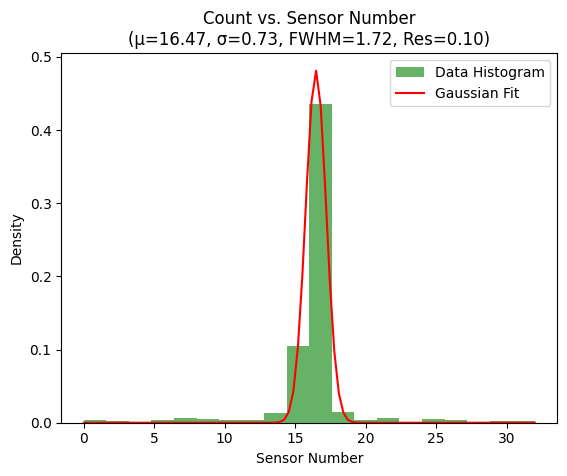

In [104]:


# Define the Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(- (x - mu)**2 / (2 * sigma**2))

# Data (use your own dataset here)
data = sensor_1[3].values

# Plot the histogram
counts, bins, _ = plt.hist(data, bins=20, density=True, alpha=0.6, color='g', label='Data Histogram')
bin_centers = 0.5 * (bins[:-1] + bins[1:])  # Calculate bin centers

# Fit the data to the Gaussian function
popt, _ = curve_fit(gaussian, bin_centers, counts, p0=[1, np.mean(data), np.std(data)])

# Extract fit parameters
A, mu, sigma = popt
print(f"Gaussian Fit Mean (μ): {mu:.2f}")
print(f"Gaussian Fit Standard Deviation (σ): {sigma:.2f}")

# Calculate FWHM and Resolution
fwhm = 2.355 * sigma  # Full Width at Half Maximum
resolution = (fwhm / mu)   # Resolution in percentage

# Print the calculated FWHM and Resolution
print(f"FWHM: {fwhm:.2f}")
print(f"Resolution: {resolution:.2f}%")

# Plot the Gaussian fit
x_range = np.linspace(data.min(), data.max(), 100)
plt.plot(x_range, gaussian(x_range, *popt), 'r-', label='Gaussian Fit')

# Add labels and legend
plt.title(f'Count vs. Sensor Number\n(μ={mu:.2f}, σ={sigma:.2f}, FWHM={fwhm:.2f}, Res={resolution:.2f})')
plt.xlabel('Sensor Number')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.show()


x values for sensor 32: [-53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -53.
 -53. -53. -53. -53. -53. -53. -53. -53. -53. -53. -5

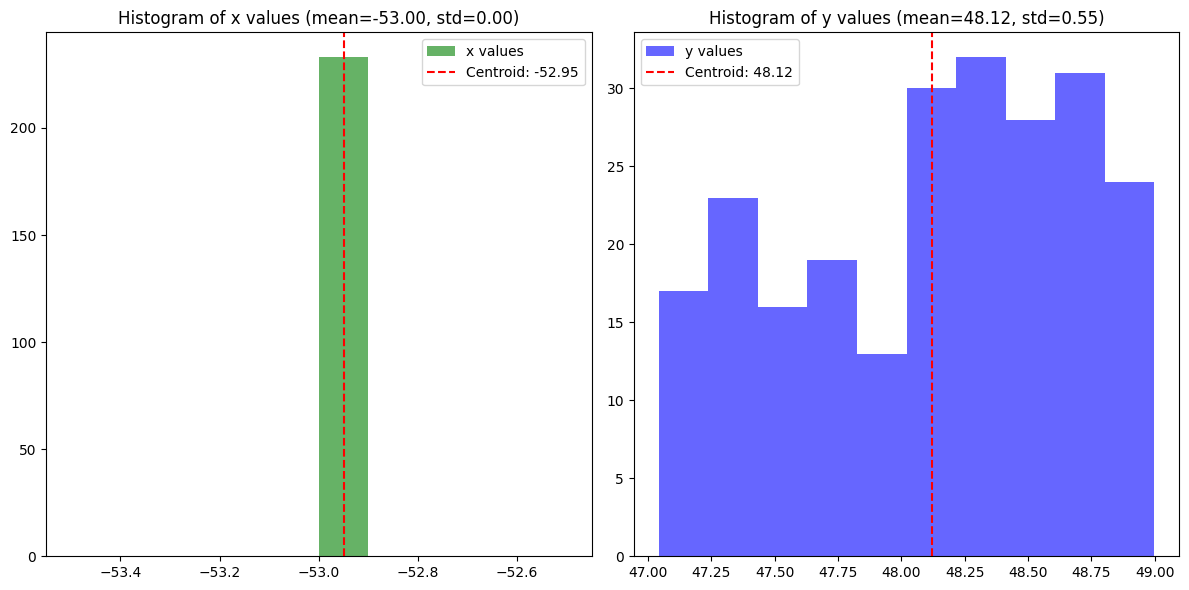

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Extract only the rows where the sensor ID is 32
sensor_data = sensor_1[sensor_1[3] == 32]

# Extract the corresponding x and y values
x_values = sensor_data[0].values  # Column 0 contains the x values
y_values = sensor_data[1].values  # Column 1 contains the y values

# Print the extracted x and y values
print(f"x values for sensor 32: {x_values}")
print(f"y values for sensor 32: {y_values}")

# Calculate mean and standard deviation for x and y values
mean_x = np.mean(x_values)
std_x = np.std(x_values)

mean_y = np.mean(y_values)
std_y = np.std(y_values)

# Calculate the centroids for x and y
# Using histograms for weighted calculations
x_hist, x_bins = np.histogram(x_values, bins=10)
x_bin_centers = (x_bins[:-1] + x_bins[1:]) / 2  # Midpoints of bins
centroid_x = np.sum(x_bin_centers * x_hist) / np.sum(x_hist)

y_hist, y_bins = np.histogram(y_values, bins=10)
y_bin_centers = (y_bins[:-1] + y_bins[1:]) / 2  # Midpoints of bins
centroid_y = np.sum(y_bin_centers * y_hist) / np.sum(y_hist)

# Print the results
print(f"Mean of x values: {mean_x}, Centroid of x: {centroid_x}")
print(f"Standard Deviation of x values: {std_x}")

print(f"Mean of y values: {mean_y}, Centroid of y: {centroid_y}")
print(f"Standard Deviation of y values: {std_y}")

# Plot the histograms for x and y values
plt.figure(figsize=(12, 6))

# Plot for x values
plt.subplot(1, 2, 1)
plt.hist(x_values, bins=10, alpha=0.6, color='g', label='x values')
plt.axvline(centroid_x, color='r', linestyle='--', label=f'Centroid: {centroid_x:.2f}')
plt.title(f'Histogram of x values (mean={mean_x:.2f}, std={std_x:.2f})')
plt.legend()

# Plot for y values
plt.subplot(1, 2, 2)
plt.hist(y_values, bins=10, alpha=0.6, color='b', label='y values')
plt.axvline(centroid_y, color='r', linestyle='--', label=f'Centroid: {centroid_y:.2f}')
plt.title(f'Histogram of y values (mean={mean_y:.2f}, std={std_y:.2f})')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()
